<a href="https://colab.research.google.com/github/harikrishna376/market_sentiment_analysis/blob/main/sentimentanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install textblob pandas requests beautifulsoup4
from textblob import TextBlob
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

print("✅ Infrastructure Ready.")

✅ Infrastructure Ready.


In [8]:
def get_live_news(ticker):
    url = f'https://finviz.com/quote.ashx?t={ticker}'
    headers = {
        'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36'
    }

    # High-impact financial keywords
    multipliers = {
        'ai': 2.5,
        'profit': 2.0,
        'surge': 2.0,
        'loss': 2.5,
        'lawsuit': 3.0,
        'growth': 1.5,
        'crash': 3.0,
        'earnings': 2.0,
        'dividend': 1.5,
        'fed': 1.8
    }

    try:
        response = requests.get(url, headers=headers)
        soup = BeautifulSoup(response.content, 'html.parser')
        news_table = soup.find(id='news-table')

        if news_table is None:
            return "❌ News table not found"

        headlines = []
        for row in news_table.find_all('tr'):
            a_tag = row.find('a')
            if a_tag is None:
                continue

            headline_text = a_tag.get_text()
            timestamp = row.td.get_text().strip() if row.td else "N/A"

            # 1. Get Base AI Score
            raw_score = TextBlob(headline_text).sentiment.polarity
            weighted_score = raw_score

            # 2. Apply Domain-Specific Weighting
            for word, boost in multipliers.items():
                if word in headline_text.lower():
                    weighted_score *= boost

            # 3. Prevent the score from exceeding the -1 to 1 range
            weighted_score = max(min(weighted_score, 1), -1)

            headlines.append([timestamp, headline_text, weighted_score])

        return pd.DataFrame(headlines, columns=['Time', 'Headline', 'Sentiment'])

    except Exception as e:
        return f"❌ Error: {e}"

In [9]:
tickers = ['NVDA', 'TSLA', 'AAPL']
results = {}

print("🚀 Starting Market Sentiment Sweep...\n")

for t in tickers:
    print(f"🔍 Analyzing {t}...")
    df = get_live_news(t)

    if isinstance(df, pd.DataFrame):
        avg_score = df['Sentiment'].mean()
        results[t] = avg_score
        print(f"   Done. Average Mood: {round(avg_score, 4)}")
    else:
        print(f"   Failed: {df}")

    # Be polite to the server
    time.sleep(1)

print("\n--- FINAL REPORT ---")
for t, score in results.items():
    mood = "🔥 BULLISH" if score > 0.05 else "❄️ BEARISH" if score < -0.05 else "😐 NEUTRAL"
    print(f"{t}: {mood} (Score: {round(score, 4)})")

🚀 Starting Market Sentiment Sweep...

🔍 Analyzing NVDA...
   Done. Average Mood: 0.1305
🔍 Analyzing TSLA...
   Done. Average Mood: 0.0121
🔍 Analyzing AAPL...
   Done. Average Mood: 0.0863

--- FINAL REPORT ---
NVDA: 🔥 BULLISH (Score: 0.1305)
TSLA: 😐 NEUTRAL (Score: 0.0121)
AAPL: 🔥 BULLISH (Score: 0.0863)


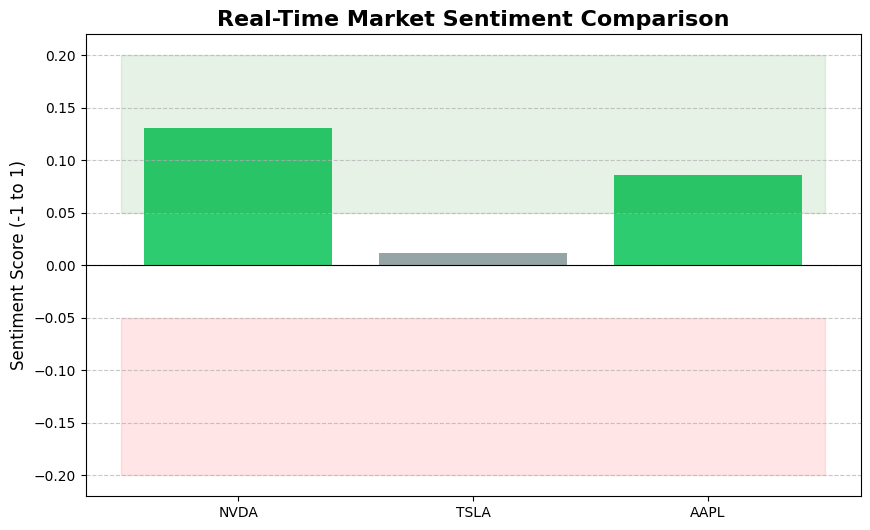

In [10]:
import matplotlib.pyplot as plt

def plot_sentiment(results):
    # Convert our results dictionary into a list of tickers and scores
    tickers = list(results.keys())
    scores = list(results.values())

    # Choose colors based on the score (Green for good, Red for bad)
    colors = ['#2ecc71' if x > 0.05 else '#e74c3c' if x < -0.05 else '#95a5a6' for x in scores]

    plt.figure(figsize=(10, 6))
    plt.bar(tickers, scores, color=colors)

    # Adding professional labels
    plt.axhline(0, color='black', linewidth=0.8) # Zero line
    plt.title('Real-Time Market Sentiment Comparison', fontsize=16, fontweight='bold')
    plt.ylabel('Sentiment Score (-1 to 1)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Highlighting the "Bullish/Bearish" zones
    plt.fill_between([-0.5, 2.5], 0.05, 0.2, color='green', alpha=0.1, label='Bullish Zone')
    plt.fill_between([-0.5, 2.5], -0.05, -0.2, color='red', alpha=0.1, label='Bearish Zone')

    plt.show()

# Call the function with your 'results' from the previous cell
plot_sentiment(results)

In [19]:
import plotly.graph_objects as go
import plotly.express as px

# 1. THE GAUGE FUNCTION
def display_gauge(avg_score, ticker):
    fig = go.Figure(go.Indicator(
        mode = "gauge+number+delta",
        value = avg_score,
        domain = {'x': [0, 1], 'y': [0, 1]},
        title = {'text': f"{ticker} Market Sentiment", 'font': {'size': 24, 'color': "white"}},
        gauge = {
            'axis': {'range': [-1, 1], 'tickwidth': 1, 'tickcolor': "white"},
            'bar': {'color': "#00f2fe"},
            'steps': [
                {'range': [-1, -0.2], 'color': '#ff4b4b'},
                {'range': [-0.2, 0.2], 'color': '#31333f'},
                {'range': [0.2, 1], 'color': '#00f2fe'}]
        }
    ))
    fig.update_layout(paper_bgcolor = '#0e1117', font = {'color': "white"})
    fig.show()

# 2. THE TIME SERIES FUNCTION
def process_time_series(df):
    # 1. Be explicit about the date format to fix UserWarning
    # Finviz uses formats like 'Oct-26-23 09:00AM' or '09:00AM'
    df['Timestamp'] = pd.to_datetime(df['Time'], errors='coerce')

    # 2. Use today's date for headlines that only have a time string
    today = pd.to_datetime('today').normalize()
    df['Timestamp'] = df['Timestamp'].apply(
        lambda x: x.replace(year=today.year, month=today.month, day=today.day)
        if pd.notnull(x) and x.year == 1970 else x
    )

    df = df.dropna(subset=['Timestamp']).sort_values('Timestamp')
    df.set_index('Timestamp', inplace=True)

    # 3. Change 'H' to 'h' to fix the FutureWarning
    trend_df = df['Sentiment'].resample('h').mean().fillna(0).reset_index()
    return trend_df

In [20]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from textblob import TextBlob

In [29]:
famous_stocks = {
    "NVIDIA": "NVDA",
    "TESLA": "TSLA",
    "APPLE": "AAPL",
    "MICROSOFT": "MSFT",
    "AMAZON": "AMZN",
    "GOOGLE": "GOOGL",
    "META": "META",
    "NETFLIX": "NFLX",
    "AMD": "AMD",
    "RELIANCE": "RELIANCE.NS" # Added a bonus for you
}

In [31]:
choice = input("Enter Stock Name (e.g., Netflix, Nvidia, Tesla): ").upper().strip()

# Check if the stock exists in our "Famous" list
if choice in famous_stocks:
    target_ticker = famous_stocks[choice]
    print(f"🕵️ Target Locked: {choice} ({target_ticker})")

    df = get_live_news_elite(target_ticker)

    if isinstance(df, pd.DataFrame):
        # 1. Gauge
        avg_score = df['Sentiment'].mean()
        display_gauge(avg_score, target_ticker)

        # 2. Trend
        trend_data = process_time_series(df)
        fig = px.line(trend_data, x='Timestamp', y='Sentiment',
                      title=f'📈 {choice} Sentiment Trend', template='plotly_dark')
        fig.show()

        # 3. Table
        display(df.sort_values(by='Sentiment', ascending=False).head(5))
    else:
        print(f"❌ Site blocked us or Ticker {target_ticker} invalid.")
else:
    print(f"⚠️ '{choice}' is not in our famous stocks list. Try NVIDIA or TESLA.")

Enter Stock Name (e.g., Netflix, Nvidia, Tesla): meta
🕵️ Target Locked: META (META)


/tmp/ipykernel_1584/1262962616.py:27: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



,Time,Headline,Sentiment,Timestamp
65,10:42AM,\r\n 'Magnificent Seven...,0.750000,2026-04-08 10:42:00
8,12:03PM,\r\n Meta unveils first...,0.625000,2026-04-08 12:03:00
7,12:06PM,\r\n Meta unveils first...,0.625000,2026-04-08 12:06:00
63,11:12AM,\r\n Meta Tests Paid In...,0.511364,2026-04-08 11:12:00
85,10:56AM,\r\n Even billionaires ...,0.375000,2026-04-08 10:56:00
